## 🦴 Orthopedic Condtion Classification

Given *biomechanical data about orthopedic patients*, let's try to predict the **condition** of a given patient.

We will use a logistic regression model to make our predictions.

Data source: https://www.kaggle.com/datasets/uciml/biomechanical-features-of-orthopedic-patients

### Importing Libraries

In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df_2c = pd.read_csv('archive/column_2C_weka.csv')
df_3c = pd.read_csv('archive/column_3C_weka.csv')

In [3]:
df_2c

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal


In [5]:
df_3c

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,Normal
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,Normal
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,Normal


In [6]:
df_2c.info()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt numeric       310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    str    
dtypes: float64(6), str(1)
memory usage: 17.1 KB


In [7]:
df_3c.info()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    str    
dtypes: float64(6), str(1)
memory usage: 17.1 KB


### Preprocessing

In [8]:
y_2c = df_2c['class'].copy()
y_3c = df_3c['class'].copy()

In [9]:
X = df_2c.drop('class', axis=1).copy()

In [10]:
X

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501
...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750


In [11]:
y_2c.unique()

<StringArray>
['Abnormal', 'Normal']
Length: 2, dtype: str

In [12]:
y_3c.unique()

<StringArray>
['Hernia', 'Spondylolisthesis', 'Normal']
Length: 3, dtype: str

In [13]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [15]:
pd.DataFrame(X)

,0,1,2,3,4,5
0,0.147086,0.501369,-0.665177,-0.184950,-1.447647,-0.708059
1,-1.245864,-0.748769,-1.453001,-1.041521,-0.264385,-0.579556
2,0.484370,0.467932,-0.099262,0.273083,-0.897686,-0.795421
3,0.511390,0.711562,-0.411339,0.126128,-1.207303,-0.402288
4,-0.626648,-0.789693,-1.274745,-0.215876,-0.733455,-0.490106
...,...,...,...,...,...,...
305,-0.731786,-0.392921,-0.860010,-0.646718,-0.035469,-0.814491
306,-0.381197,0.318116,-1.225991,-0.726682,-0.267362,-0.712503
307,0.055201,0.515618,-0.310977,-0.313564,0.582893,-0.773488
308,-0.885823,-0.885660,-0.558613,-0.477128,0.047021,-0.695548


In [16]:
X_train, X_test, y_2c_train, y_2c_test, y_3c_train, y_3c_test = train_test_split(X, y_2c, y_3c, train_size = 0.7, random_state=123)

### Training

In [17]:
model_2c = LogisticRegressionCV()
model_2c.fit(X_train, y_2c_train)

model_3c = LogisticRegressionCV()
model_3c.fit(X_train, y_3c_train)

print("Models trained.")

D:\miniconda3\envs\tfenv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
D:\miniconda3\envs\tfenv\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
D:\miniconda3\envs\tfenv\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to 

Models trained.


#### Generate Predictions

In [21]:
y_2c_true = np.array(y_2c_test)
y_2c_pred = model_2c.predict(X_test)

y_3c_true = np.array(y_3c_test)
y_3c_pred = model_3c.predict(X_test)

### Results

##### Get Accuracies

In [26]:
acc_2c = model_2c.score(X_test, y_2c_test)
acc_3c = model_3c.score(X_test, y_3c_test)

In [24]:
# Create Confusion matrices and classification reports
cm_2c = confusion_matrix(y_2c_true, y_2c_pred)
cm_3c = confusion_matrix(y_3c_true, y_3c_pred)

In [40]:
clr_2c = classification_report(y_2c_true, y_2c_pred)
clr_3c = classification_report(y_3c_true, y_3c_pred)

#### 2-Class Model Results

In [28]:
print("2-Class Accuracy: {:.4f}".format(acc_2c))

2-Class Accuracy: 0.8280


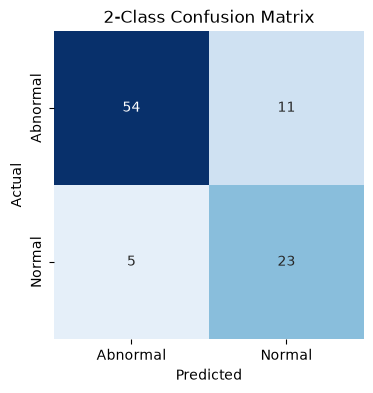

In [34]:
plt.figure(figsize=(4,4))
sns.heatmap(cm_2c, annot=True, fmt='g', cbar=False, vmin=0,cmap='Blues')
plt.xticks(np.arange(2) + 0.5, ['Abnormal', 'Normal'])
plt.yticks(np.arange(2) + 0.5, ['Abnormal', 'Normal'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("2-Class Confusion Matrix")
plt.show()

In [42]:
print(clr_2c)

              precision    recall  f1-score   support

    Abnormal       0.92      0.83      0.87        65
      Normal       0.68      0.82      0.74        28

    accuracy                           0.83        93
   macro avg       0.80      0.83      0.81        93
weighted avg       0.84      0.83      0.83        93



#### 3-Class Model Results

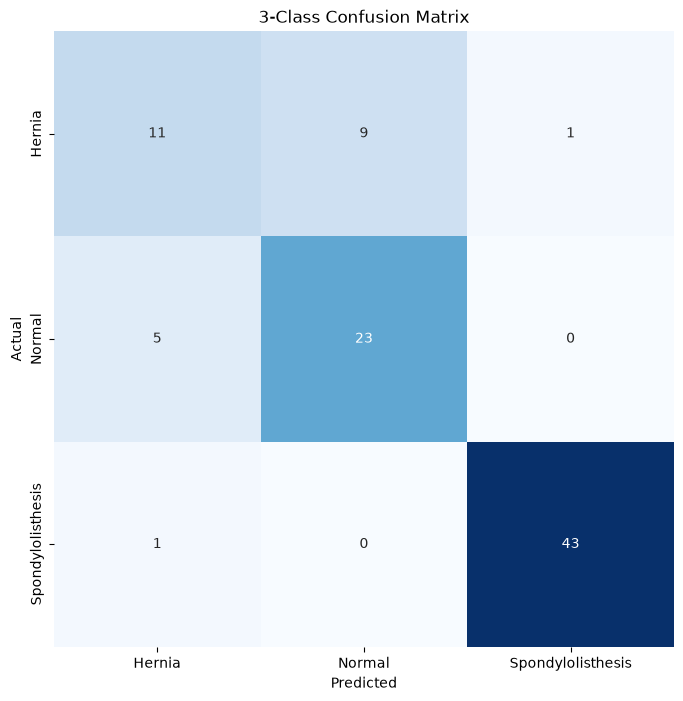

In [43]:
plt.figure(figsize=(8,8))
sns.heatmap(cm_3c, annot=True, fmt='g', cbar=False, vmin=0,cmap='Blues')
plt.xticks(np.arange(3) + 0.5, ['Hernia', 'Normal', 'Spondylolisthesis'])
plt.yticks(np.arange(3) + 0.5, ['Hernia', 'Normal', 'Spondylolisthesis'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("3-Class Confusion Matrix")
plt.show()

In [44]:
print("3-Class Accuracy: {:.4f}".format(acc_3c))

3-Class Accuracy: 0.8280


In [45]:
print(clr_3c)

                   precision    recall  f1-score   support

           Hernia       0.65      0.52      0.58        21
           Normal       0.72      0.82      0.77        28
Spondylolisthesis       0.98      0.98      0.98        44

         accuracy                           0.83        93
        macro avg       0.78      0.77      0.77        93
     weighted avg       0.82      0.83      0.82        93

